# Milestone 6 — Zero-Shot Transfer, Fine-Tuning, and Data Efficiency

In [1]:
import sys, copy, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds, evaluate as ev
from gridfm import train as tr
from gridfm.model import GridFMv01, gridfm_loss
from torch_geometric.loader import DataLoader

RAW_DIR, PROC_DIR = ROOT / "data" / "raw", ROOT / "data" / "processed"
FIG_DIR, STATS_DIR = ROOT / "results" / "figures" / "m6", ROOT / "results" / "m6_stats"
for d in [FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

BASE39 = json.load(open(ROOT / "results" / "m2_stats" / "base_mva.json"))["case39"]
train39 = ds.load_processed(PROC_DIR, "case39", "train")
val39 = ds.load_processed(PROC_DIR, "case39", "val")
test39 = ds.load_processed(PROC_DIR, "case39", "test")
print("case39 splits: %d / %d / %d | base %.0f MVA" %
      (len(train39), len(val39), len(test39), BASE39))

def load_pretrained():
    m = GridFMv01(per_head=32, heads=4, num_layers=4, dropout=0.1)
    st = torch.load(ROOT / "checkpoints" / "final_pretrain_best.pt", weights_only=False)
    m.load_state_dict(st["model"])
    return m

case39 splits: 977 / 126 / 120 | base 1100 MVA

## Question 1 — Zero-shot: an unseen grid, no training

In [2]:
model_zs = load_pretrained()
zs_df, zs_det, _ = ev.pf_evaluate(model_zs, test39)
print("zero-shot case39: mean Pr %.2f MW | mean Qr %.2f MVar"
      % (zs_df.p_res_mw.mean(), zs_df.q_res_mvar.mean()))
zs_df.to_csv(STATS_DIR / "zeroshot_case39.csv", index=False)

zero-shot case39: mean Pr 866.67 MW | mean Qr 338.33 MVar

In [3]:
import multiprocessing as mp

meta39 = pd.read_csv(RAW_DIR / "case39" / "meta.csv").set_index("scenario")
ybus39 = pd.read_csv(RAW_DIR / "case39" / "ybus.csv")
sids = [int(g.scenario) for g in test39]
tasks = [("case39", s, float(meta39.loc[s, "scale"]),
          meta39.loc[s, "removed"] if isinstance(meta39.loc[s, "removed"], str) else "")
         for s in sids]
if __name__ == "__main__":
    with mp.Pool(10) as pool:
        states = pool.map(ev.dc_state_worker, tasks, chunksize=4)
dc_rows = [{"scenario": st["scenario"],
            "p_res_mw": ev.dc_residual_mw(st["theta"], st["p_inj_mw"],
                                          ybus39[ybus39.scenario == st["scenario"]])}
           for st in states if st["status"] == "ok"]
dc39 = pd.DataFrame(dc_rows)
dc39.to_csv(STATS_DIR / "dc_case39.csv", index=False)
print("DC solver case39: mean Pr %.2f MW (%d/%d scenarios)"
      % (dc39.p_res_mw.mean(), len(dc39), len(tasks)))

DC solver case39: mean Pr 6.79 MW (120/120 scenarios)

## Question 2 — Fine-tuning: pretrained head start vs from scratch

In [4]:
def val_pr_mw(model, loader, base_mva):
    model.eval()
    tot, n = 0.0, 0
    for b in loader:
        xm, m = ds.pf_mask(b.x)
        with torch.no_grad():
            pred = model(xm, b.edge_index, b.edge_attr)
        m6 = m[:, :6]
        x_mix = torch.cat([torch.where(m6, pred, b.x[:, :6]), b.x[:, 6:]], dim=1)
        dp, _ = ds.pbe_residual(x_mix, b.ybus_index, b.ybus_g, b.ybus_b)
        tot += float(dp.abs().sum()) * base_mva
        n += len(dp)
    return tot / n


def finetune(start_from, train_graphs, seed, epochs=80, lr=3e-4):
    torch.manual_seed(seed)
    if start_from == "pretrained":
        model = load_pretrained()
    else:
        model = GridFMv01(per_head=32, heads=4, num_layers=4, dropout=0.1)
    gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True, generator=gen)
    vloader = DataLoader(val39, batch_size=64, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.7, patience=10)
    curve, best_pr, best_state = [], float("inf"), None
    for ep in range(epochs):
        tr.run_epoch(model, train_loader, "cpu", opt=opt, clip=1.0, mask_fn=ds.pf_mask)
        pr = val_pr_mw(model, vloader, BASE39)
        sched.step(pr)
        curve.append(pr)
        if pr < best_pr:
            best_pr, best_state = pr, copy.deepcopy(model.state_dict())
    return curve, best_pr, best_state

SEEDS = [0, 1, 2]
curves, best_states = {"pretrained": [], "scratch": []}, {}
t0 = time.time()
for variant in ["pretrained", "scratch"]:
    for seed in SEEDS:
        c, bp, bs = finetune(variant, train39, seed)
        curves[variant].append(c)
        if variant not in best_states or bp < best_states[variant][0]:
            best_states[variant] = (bp, bs)
        print("%-10s seed %d: best val Pr %.2f MW" % (variant, seed, bp))
print("6 runs in %.1f min" % ((time.time() - t0) / 60))
json.dump({k: v for k, v in curves.items()}, open(STATS_DIR / "ft_curves.json", "w"))

pretrained seed 0: best val Pr 47.11 MW

pretrained seed 1: best val Pr 45.76 MW

pretrained seed 2: best val Pr 46.46 MW

scratch    seed 0: best val Pr 135.05 MW

scratch    seed 1: best val Pr 135.82 MW

scratch    seed 2: best val Pr 135.14 MW

6 runs in 11.2 min

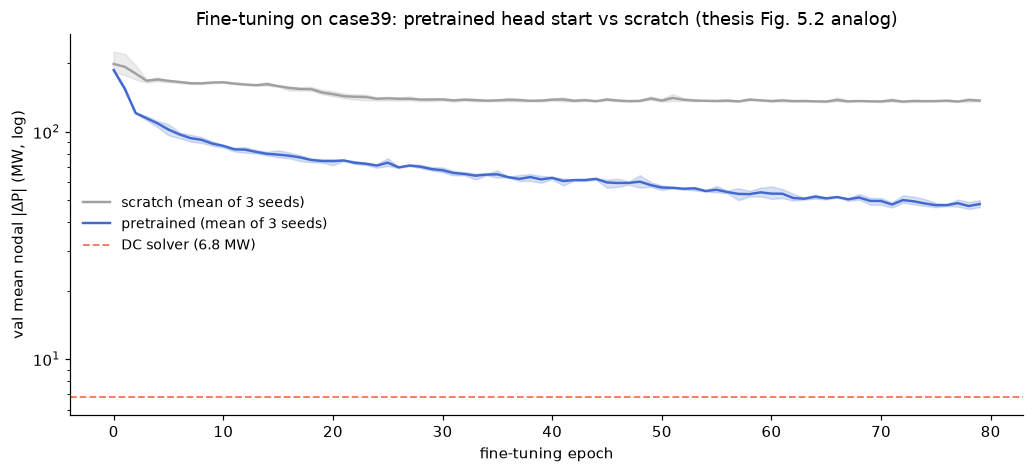

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
for variant, col in [("scratch", "#A0A0A0"), ("pretrained", "#4269D0")]:
    arr = np.array(curves[variant])
    ax.plot(arr.mean(0), color=col, lw=1.6, label="%s (mean of 3 seeds)" % variant)
    ax.fill_between(range(arr.shape[1]), arr.min(0), arr.max(0), color=col, alpha=0.2)
ax.axhline(dc39.p_res_mw.mean(), color="#FF725C", ls="--", lw=1.2,
           label="DC solver (%.1f MW)" % dc39.p_res_mw.mean())
ax.set_yscale("log")
ax.set(xlabel="fine-tuning epoch", ylabel="val mean nodal |ΔP| (MW, log)",
       title="Fine-tuning on case39: pretrained head start vs scratch (thesis Fig. 5.2 analog)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_convergence.png", bbox_inches="tight")
plt.show()

## Question 3 — Data efficiency: fine-tuning on a fraction of the data

pretrained +  25% data: best val Pr 74.46 MW

pretrained +  50% data: best val Pr 61.55 MW

pretrained +  75% data: best val Pr 52.84 MW

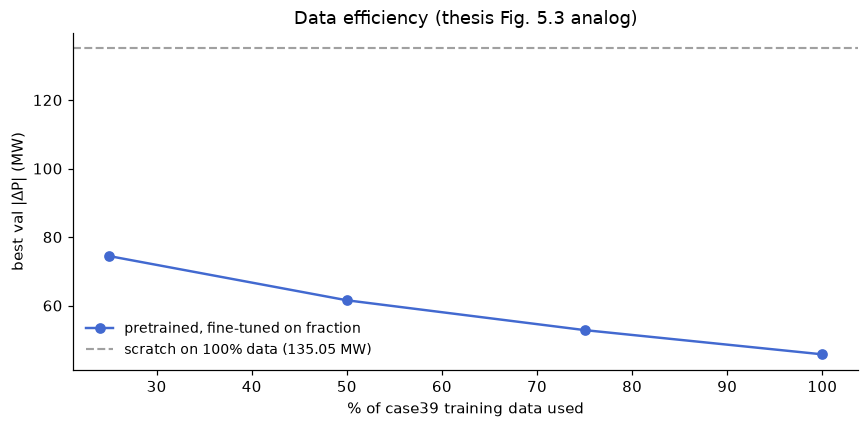

In [6]:
rng = np.random.RandomState(0)
frac_results = {}
for frac in [0.25, 0.5, 0.75]:
    idx = rng.choice(len(train39), size=int(frac * len(train39)), replace=False)
    subset = [train39[i] for i in idx]
    _, bp, _ = finetune("pretrained", subset, seed=0)
    frac_results[frac] = bp
    print("pretrained + %3.0f%% data: best val Pr %.2f MW" % (100 * frac, bp))
frac_results[1.0] = best_states["pretrained"][0]
scratch_100 = best_states["scratch"][0]
json.dump({str(k): v for k, v in frac_results.items()},
          open(STATS_DIR / "data_efficiency.json", "w"))

fig, ax = plt.subplots(figsize=(8, 4))
fr = sorted(frac_results)
ax.plot([100 * f for f in fr], [frac_results[f] for f in fr], "o-",
        color="#4269D0", lw=1.6, ms=6, label="pretrained, fine-tuned on fraction")
ax.axhline(scratch_100, color="#A0A0A0", ls="--", lw=1.4,
           label="scratch on 100%% data (%.2f MW)" % scratch_100)
ax.set(xlabel="% of case39 training data used", ylabel="best val |ΔP| (MW)",
       title="Data efficiency (thesis Fig. 5.3 analog)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_data_efficiency.png", bbox_inches="tight")
plt.show()

## Final scoreboard on the case39 test set

                   Pr (MW)  Qr (MVar)
DC solver             6.79        NaN
GridFM zero-shot    866.67     338.33
GridFM scratch      131.40     290.98
GridFM fine-tuned    41.43      35.50


thesis Table 5.4, case39: fine-tuned v0.1 Pr 2.21 MW, Qr 0.97 MVar; DC 13.27 MW

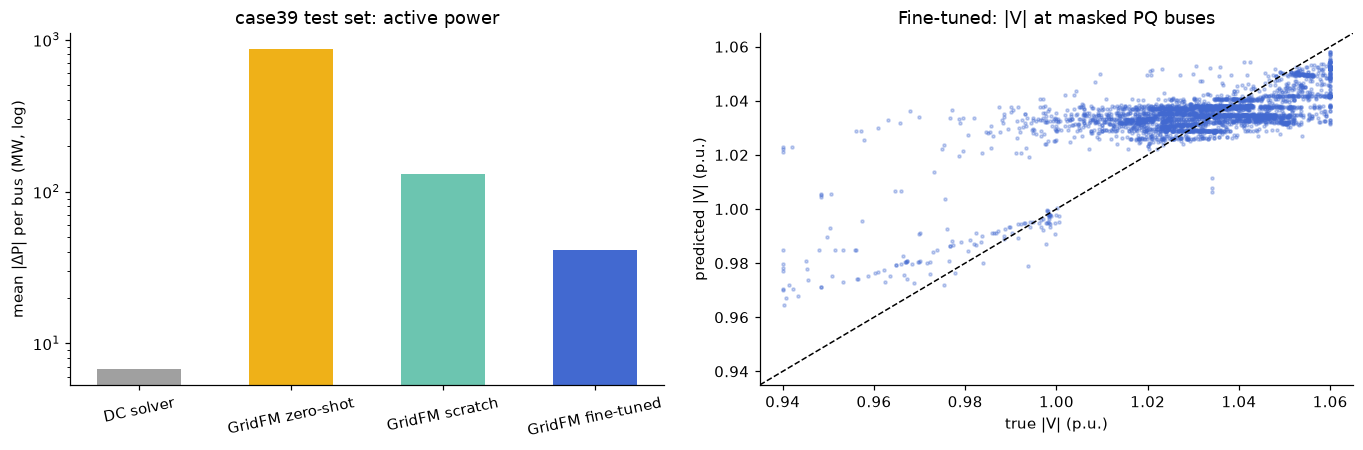

fine-tuned |V| error: mean 0.0103 p.u. | p95 0.0282 p.u.

In [7]:
def test_eval(state_dict):
    m = GridFMv01(per_head=32, heads=4, num_layers=4, dropout=0.1)
    m.load_state_dict(state_dict)
    df, det, _ = ev.pf_evaluate(m, test39)
    return df, det, m

ft_df, ft_det, ft_model = test_eval(best_states["pretrained"][1])
sc_df, _, _ = test_eval(best_states["scratch"][1])
torch.save({"model": best_states["pretrained"][1]},
           ROOT / "checkpoints" / "final_finetune39_best.pt")

score = pd.DataFrame({
    "Pr (MW)": {"DC solver": dc39.p_res_mw.mean(),
                "GridFM zero-shot": zs_df.p_res_mw.mean(),
                "GridFM scratch": sc_df.p_res_mw.mean(),
                "GridFM fine-tuned": ft_df.p_res_mw.mean()},
    "Qr (MVar)": {"DC solver": np.nan,
                  "GridFM zero-shot": zs_df.q_res_mvar.mean(),
                  "GridFM scratch": sc_df.q_res_mvar.mean(),
                  "GridFM fine-tuned": ft_df.q_res_mvar.mean()},
})
print(score.round(2).to_string())
print("\nthesis Table 5.4, case39: fine-tuned v0.1 Pr 2.21 MW, Qr 0.97 MVar; DC 13.27 MW")
score.to_csv(STATS_DIR / "scoreboard_case39.csv")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
labels = list(score.index)
colors = ["#A0A0A0", "#EFB118", "#6CC5B0", "#4269D0"]
axes[0].bar(labels, score["Pr (MW)"].values, color=colors, width=0.55)
axes[0].set_yscale("log")
axes[0].set(ylabel="mean |ΔP| per bus (MW, log)", title="case39 test set: active power")
axes[0].tick_params(axis="x", rotation=12)

vm_t, vm_p = np.array(ft_det["vm_true"]), np.array(ft_det["vm_pred"])
axes[1].scatter(vm_t, vm_p, s=4, alpha=0.3, color="#4269D0")
lims = [min(vm_t.min(), vm_p.min()) - 0.005, max(vm_t.max(), vm_p.max()) + 0.005]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set(xlabel="true |V| (p.u.)", ylabel="predicted |V| (p.u.)",
            title="Fine-tuned: |V| at masked PQ buses", xlim=lims, ylim=lims)
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_final_scoreboard.png", bbox_inches="tight")
plt.show()
vm_err = np.abs(vm_p - vm_t)
print("fine-tuned |V| error: mean %.4f p.u. | p95 %.4f p.u." %
      (vm_err.mean(), np.percentile(vm_err, 95)))